In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_bgr = cv2.imread("/home/ars/cv-labs-sem8/lab1/sample_image.jpg")
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

gray = np.mean(img, axis=2).astype(np.uint8)

In [5]:
kernel_size = 5
pad = kernel_size // 2
padded = np.pad(gray, pad, mode="edge")
gauss = np.zeros_like(gray)


In [6]:
sigma = 1.0
ax = np.arange(-pad, pad + 1)
xx, yy = np.meshgrid(ax, ax)
kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
kernel = kernel / np.sum(kernel)

for i in range(gray.shape[0]):
    for j in range(gray.shape[1]):
        region = padded[i:i+kernel_size, j:j+kernel_size]
        gauss[i, j] = np.sum(region * kernel)

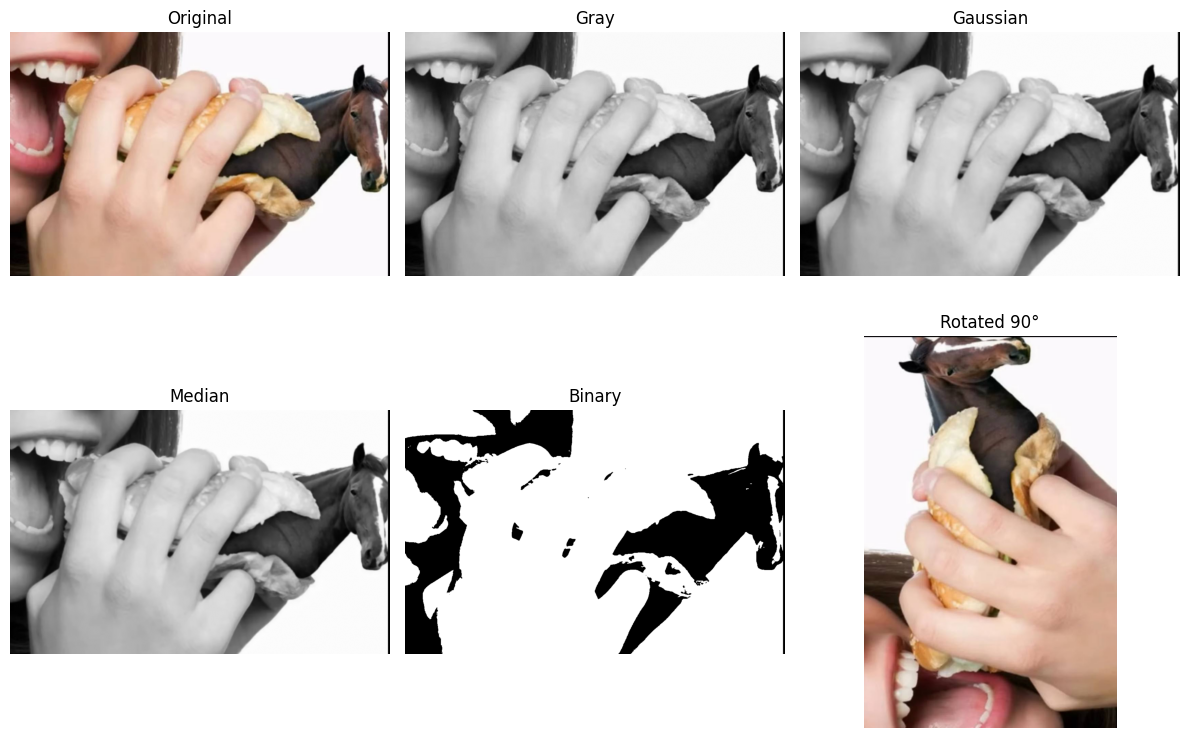

In [7]:
median = np.zeros_like(gray)
for i in range(gray.shape[0]):
    for j in range(gray.shape[1]):
        region = padded[i:i+kernel_size, j:j+kernel_size]
        median[i, j] = np.median(region)

binary = np.where(gray > 128, 255, 0).astype(np.uint8)

rotated = np.rot90(img)

plt.figure(figsize=(12,8))
plt.subplot(2,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(2,3,2); plt.imshow(gray, cmap="gray"); plt.title("Gray"); plt.axis("off")
plt.subplot(2,3,3); plt.imshow(gauss, cmap="gray"); plt.title("Gaussian"); plt.axis("off")
plt.subplot(2,3,4); plt.imshow(median, cmap="gray"); plt.title("Median"); plt.axis("off")
plt.subplot(2,3,5); plt.imshow(binary, cmap="gray"); plt.title("Binary"); plt.axis("off")
plt.subplot(2,3,6); plt.imshow(rotated); plt.title("Rotated 90°"); plt.axis("off")
plt.tight_layout()
plt.show()